In [14]:
## ⚙️ Global Variables & Config

# --- General Settings ---
SEED = 88
logs_dir = "tensorboard"

# --- File Paths ---
PATH_TRAIN = "/kaggle/input/the-pirate-pain-dataset/pirate_pain_train.csv"
PATH_TEST = "/kaggle/input/the-pirate-pain-dataset/pirate_pain_test.csv"
PATH_TRAIN_LABELS = "/kaggle/input/the-pirate-pain-dataset/pirate_pain_train_labels.csv"

# --- Data Split ---
VAL_SPLIT_SIZE = 0.20

# --- Optuna Tuning Settings ---
N_TRIALS_STUDY_1 = 25  # Number of trials for the first (combined) study
N_TRIALS_STUDY_2 = 25  # Number of trials for the second (M2-only) study
TUNING_EPOCHS = 200    # Max epochs per trial
TUNING_PATIENCE = 20     # Patience for early stopping during tuning
TUNING_BATCH_SIZE = 64

# --- Final Training Settings ---
FINAL_EPOCHS = 500
FINAL_PATIENCE = 40
FINAL_BATCH_SIZE = 64

# --- Model Classes (Do not change unless you modify the labels) ---
NUM_CLASSES_M1 = 2  # no_pain vs. pain
NUM_CLASSES_M2 = 2  # low_pain vs. high_pain

In [15]:
## 📚 Imports & Setup

import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np
import copy
import shutil
from itertools import product
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from pandas.plotting import autocorrelation_plot

# Scikit-learn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, 
    recall_score, confusion_matrix, classification_report
)

# PyTorch
import torch
from torch import nn
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# Set all seeds
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)

# TensorBoard setup
!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p models

# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

# List input files (Kaggle environment)
print("\nInput files:")
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard
PyTorch version: 2.6.0+cu124
Device: cuda

Input files:
/kaggle/input/the-pirate-pain-dataset/sample_submission.csv
/kaggle/input/the-pirate-pain-dataset/pirate_pain_test.csv
/kaggle/input/the-pirate-pain-dataset/pirate_pain_train_labels.csv
/kaggle/input/the-pirate-pain-dataset/pirate_pain_train.csv


## ⏳ Data Loading & Preprocessing

In [16]:
## ⏳ Data Loading & Preprocessing

print("Loading data...")
# Load the dataset from CSV files using global paths
df_train = pd.read_csv(PATH_TRAIN)
df_public_test = pd.read_csv(PATH_TEST)
df_labels = pd.read_csv(PATH_TRAIN_LABELS)

# --- Preprocessing ---
def preProcess(df):
    # Combine one-hot features into a single categorical feature
    df['merged_n_features'] = np.where(
        (df['n_legs'] == 'two') & (df['n_hands'] == 'two') & (df['n_eyes'] == 'two'),
        0, 1
    )
    df.drop(columns=['n_legs', 'n_hands', 'n_eyes'], inplace=True)

print("Running initial feature engineering...")
preProcess(df_train)
preProcess(df_public_test)

# --- Define Feature Columns ---
continuous_feature_cols = [col for col in df_train.columns if col not in ["sample_index", "time"]]
categorical_feature_cols = ['time']
CONTINUOUS_FEATURE_SIZE = len(continuous_feature_cols)
TIME_VOCAB_SIZE = int(df_train['time'].max() + 1)

print(f"Continuous features: {CONTINUOUS_FEATURE_SIZE}, Categorical features: {len(categorical_feature_cols)}")

# --- Scaling ---
print("Running data scaling...")
scaler = MinMaxScaler()
df_train[continuous_feature_cols] = scaler.fit_transform(df_train[continuous_feature_cols])
df_public_test[continuous_feature_cols] = scaler.transform(df_public_test[continuous_feature_cols])

# --- Label Encoding ---
print("Applying 2-model label encoding...")
# 1. Labels for Model 1 (no_pain vs. pain)
df_labels['label_encoded_m1'] = df_labels['label'].apply(lambda x: 0 if x == 'no_pain' else 1)

# 2. Labels for Model 2 (low_pain vs. high_pain)
def encode_model2(label):
    if label == 'low_pain': return 0
    elif label == 'high_pain': return 1
    else: return -1  # For 'no_pain' samples
df_labels['label_encoded_m2'] = df_labels['label'].map(encode_model2)

# 3. 3-class numeric label (for final validation)
label_map_3class = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
df_labels['label_encoded_3class'] = df_labels['label'].map(label_map_3class)

print("--- Preprocessing & Labeling Complete ---")
print(df_labels['label_encoded_m1'].value_counts())
print(df_labels['label_encoded_m2'].value_counts())

# --- Train/Val Split ---
print("\n--- Splitting data for Model 1 & 2 ---")
user_labels = df_labels.copy()

# Stratify based on the ORIGINAL 3-class label
train_users, val_users = train_test_split(
    user_labels['sample_index'],
    test_size=VAL_SPLIT_SIZE,
    stratify=user_labels['label'],
    random_state=SEED
)

df_train_full = df_train.copy()

# Data for Model 1 (All samples)
df_train_fold_m1 = df_train_full[df_train_full['sample_index'].isin(train_users)]
df_val_fold_m1 = df_train_full[df_train_full['sample_index'].isin(val_users)]

cols_to_merge_m1 = ['sample_index', 'label_encoded_m1', 'label_encoded_3class']
df_train_fold_m1 = df_train_fold_m1.merge(user_labels[cols_to_merge_m1], on='sample_index', how='left')
df_val_fold_m1 = df_val_fold_m1.merge(user_labels[cols_to_merge_m1], on='sample_index', how='left')
print(f"Model 1 Train shape: {df_train_fold_m1.shape}, Val shape: {df_val_fold_m1.shape}")

# Data for Model 2 (Only 'low_pain' and 'high_pain' samples)
df_train_full_labeled = df_train.merge(user_labels, on='sample_index', how='left')
df_train_fold_m2 = df_train_full_labeled[
    (df_train_full_labeled['sample_index'].isin(train_users)) &
    (df_train_full_labeled['label_encoded_m1'] == 1) # Only "pain" samples
]
df_val_fold_m2 = df_train_full_labeled[
    (df_train_full_labeled['sample_index'].isin(val_users)) &
    (df_train_full_labeled['label_encoded_m1'] == 1) # Only "pain" samples
]
print(f"Model 2 Train shape: {df_train_fold_m2.shape}, Val shape: {df_val_fold_m2.shape}")

# Drop the original string label (no longer needed)
df_train_fold_m2 = df_train_fold_m2.drop(columns=['label'])
df_val_fold_m2 = df_val_fold_m2.drop(columns=['label'])

# --- Dtype Casting ---
print("\nCasting data types...")
for df in [df_train_fold_m1, df_val_fold_m1, df_train_fold_m2, df_val_fold_m2]:
    for col in continuous_feature_cols:
        if col in df.columns: df[col] = df[col].astype('float32')
    for col in categorical_feature_cols:
         if col in df.columns: df[col] = df[col].astype('int64')

df_train_fold_m1['label_encoded_m1'] = df_train_fold_m1['label_encoded_m1'].astype('int64')
df_val_fold_m1['label_encoded_m1'] = df_val_fold_m1['label_encoded_m1'].astype('int64')
df_train_fold_m1['label_encoded_3class'] = df_train_fold_m1['label_encoded_3class'].astype('int64')
df_val_fold_m1['label_encoded_3class'] = df_val_fold_m1['label_encoded_3class'].astype('int64')
df_train_fold_m2['label_encoded_m2'] = df_train_fold_m2['label_encoded_m2'].astype('int64')
df_val_fold_m2['label_encoded_m2'] = df_val_fold_m2['label_encoded_m2'].astype('int64')

Loading data...
Running initial feature engineering...
Continuous features: 36, Categorical features: 1
Running data scaling...
Applying 2-model label encoding...
--- Preprocessing & Labeling Complete ---
label_encoded_m1
0    511
1    150
Name: count, dtype: int64
label_encoded_m2
-1    511
 0     94
 1     56
Name: count, dtype: int64

--- Splitting data for Model 1 & 2 ---
Model 1 Train shape: (84480, 40), Val shape: (21280, 40)
Model 2 Train shape: (19200, 42), Val shape: (4800, 42)

Casting data types...


## 🔎 Exploratory Data Analysis

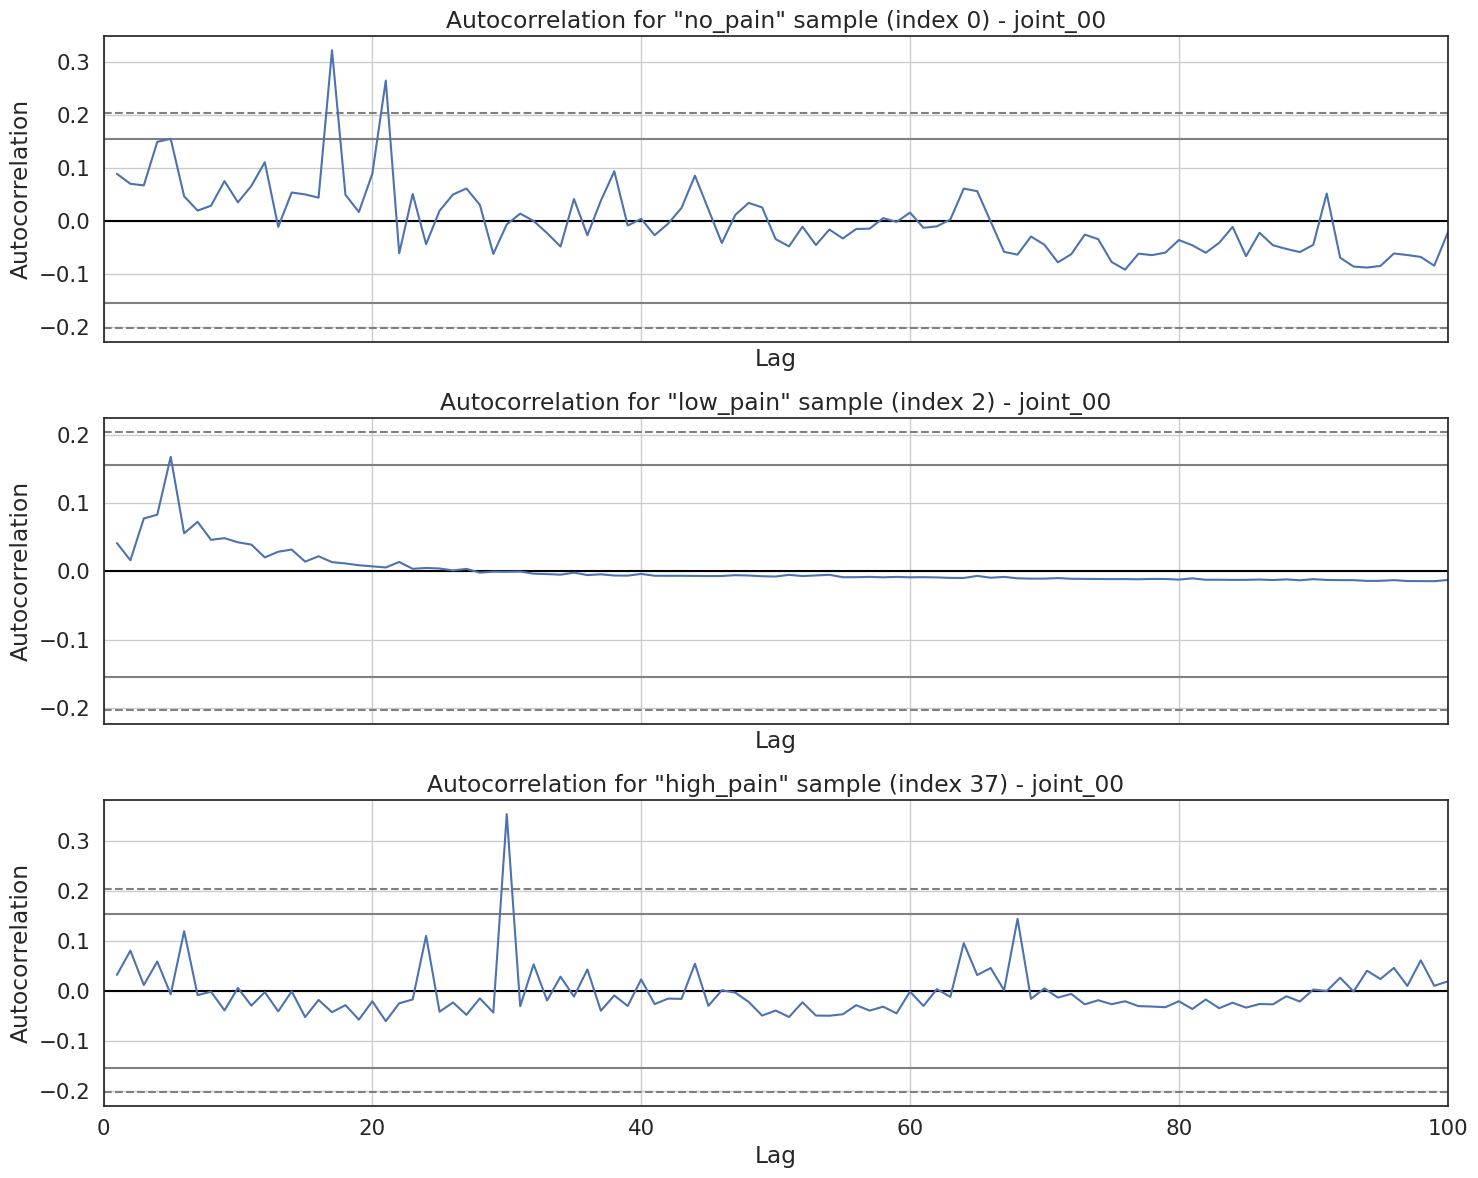

In [17]:
# This cell is for exploration and not required for the final pipeline
from pandas.plotting import autocorrelation_plot

# --- 1. Get one sample_index for each pain class ---
try:
    no_pain_sample = df_labels[df_labels['label'] == 'no_pain']['sample_index'].iloc[0]
    low_pain_sample = df_labels[df_labels['label'] == 'low_pain']['sample_index'].iloc[0]
    high_pain_sample = df_labels[df_labels['label'] == 'high_pain']['sample_index'].iloc[0]

    # --- 2. Get the raw time series data for one joint (e.g., joint_00) ---
    # We use df_train (loaded in Cell 157) because it's the raw, unscaled data
    ts_no_pain = df_train[df_train['sample_index'] == no_pain_sample]['joint_23']
    ts_low_pain = df_train[df_train['sample_index'] == low_pain_sample]['joint_23']
    ts_high_pain = df_train[df_train['sample_index'] == high_pain_sample]['joint_23']

    # --- 3. Create the plots ---
    fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
    
    autocorrelation_plot(ts_no_pain, ax=axes[0])
    axes[0].set_title(f'Autocorrelation for "no_pain" sample (index {no_pain_sample}) - joint_00')
    
    autocorrelation_plot(ts_low_pain, ax=axes[1])
    axes[1].set_title(f'Autocorrelation for "low_pain" sample (index {low_pain_sample}) - joint_00')
    
    autocorrelation_plot(ts_high_pain, ax=axes[2])
    axes[2].set_title(f'Autocorrelation for "high_pain" sample (index {high_pain_sample}) - joint_00')

    # Limit the x-axis (lag) to a reasonable amount, e.g., 100 timesteps
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not plot autocorrelation: {e}")
    print("This may happen if one of the classes has no samples in the initial data view.")

## 🛠️ Model & Utility Functions

In [27]:
## 🛠️ Model & Utility Functions

# --- 1. Data Building Functions ---

def build_sequences(df, continuous_cols, categorical_cols, id_col='sample_index', label_col='label_encoded', window=200, stride=200):
    """Builds padded, windowed sequences from the dataframe."""
    num_continuous_features = len(continuous_cols)
    num_categorical_features = len(categorical_cols)
    dataset_continuous, dataset_categorical, labels = [], [], []
    
    for sample_id in df[id_col].unique():
        temp_df = df[df[id_col] == sample_id]
        temp_continuous = temp_df[continuous_cols].values.astype('float32')
        temp_categorical = temp_df[categorical_cols].values.astype('int64') 
        label = temp_df[label_col].values[0]
        
        # Pad the end of the sequence to be a multiple of the window size
        padding_len = (window - len(temp_df) % window) % window
        if padding_len > 0:
            padding_continuous = np.zeros((padding_len, num_continuous_features), dtype='float32')
            padding_categorical = np.zeros((padding_len, num_categorical_features), dtype='int64')
            temp_continuous = np.concatenate((temp_continuous, padding_continuous))
            temp_categorical = np.concatenate((temp_categorical, padding_categorical))
            
        idx = 0
        while idx + window <= len(temp_continuous):
            dataset_continuous.append(temp_continuous[idx:idx + window])
            dataset_categorical.append(temp_categorical[idx:idx + window])
            labels.append(label)
            idx += stride
            
    return np.array(dataset_continuous), np.array(dataset_categorical), np.array(labels)

def make_loader(ds, batch_size, shuffle, drop_last):
    """Creates an optimized PyTorch DataLoader."""
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
        num_workers=num_workers, pin_memory=True, 
        pin_memory_device="cuda" if torch.cuda.is_available() else "",
        prefetch_factor=4,
    )

# --- 2. Model Definition ---

class RecurrentAttentionClassifier(nn.Module):
    def __init__(
            self, continuous_input_size, time_vocab_size, time_embedding_dim,
            cnn_out_channels, 
            hidden_size, num_layers, num_classes, rnn_type='GRU',
            bidirectional=False, dropout_rate=0.2, use_layer_norm=False
            ):
        super().__init__()
        self.rnn_type, self.num_layers, self.hidden_size = rnn_type, num_layers, hidden_size
        self.bidirectional, self.use_layer_norm = bidirectional, use_layer_norm
        
        self.time_embedding = nn.Embedding(time_vocab_size, time_embedding_dim)
        
        rnn_input_size = continuous_input_size + time_embedding_dim
        
        # 1D Convolutional Layer
        self.conv1d = nn.Conv1d(
            in_channels=rnn_input_size, 
            out_channels=cnn_out_channels, 
            kernel_size=3, 
            padding=1, # padding=1 keeps sequence length the same
            bias=False
        )
        self.relu = nn.ReLU()
        
        rnn_map = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}
        rnn_module = rnn_map[rnn_type]
        dropout_val = dropout_rate if num_layers > 1 else 0
        
        # RNN Layer (input size is now the output of the CNN)
        self.rnn = rnn_module(
            input_size=cnn_out_channels, 
            hidden_size=hidden_size, 
            num_layers=num_layers,
            batch_first=True, 
            bidirectional=bidirectional, 
            dropout=dropout_val
        )
        
        head_input_size = hidden_size * 2 if self.bidirectional else hidden_size
            
        if self.use_layer_norm:
            self.norm_layer = nn.LayerNorm(head_input_size)
            
        self.attention_scorer = nn.Linear(head_input_size, 1)
        self.classifier = nn.Linear(head_input_size, num_classes)

    def forward(self, x_cont, x_cat):
        time_embeds = self.time_embedding(x_cat.long().squeeze(-1)) 
        combined_input = torch.cat((x_cont, time_embeds), dim=2) # Shape: (Batch, SeqLen, Features)
        
        # Apply CNN
        x = combined_input.permute(0, 2, 1) # (Batch, Features, SeqLen)
        x = self.conv1d(x)
        x = self.relu(x)
        x = x.permute(0, 2, 1) # (Batch, SeqLen, CNN_Features)
        
        # Pass CNN output to the RNN
        rnn_out, _ = self.rnn(x) 
        
        # Attention and Classifier
        attn_scores = self.attention_scorer(rnn_out)
        attn_weights = torch.softmax(attn_scores, dim=1) 
        context_vector = torch.sum(attn_weights * rnn_out, dim=1)
        
        if self.use_layer_norm:
            context_vector = self.norm_layer(context_vector)
            
        return self.classifier(context_vector)

# --- 3. Training & Validation Loop Functions ---

def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, 
                    l1_lambda=0, l2_lambda=0, augmentation_noise_std=0.0):
    model.train()
    running_loss = 0.0
    all_predictions, all_targets = [], []
    for inputs_cont, inputs_cat, targets in train_loader:
        inputs_cont, inputs_cat, targets = inputs_cont.to(device), inputs_cat.to(device), targets.to(device)
        if augmentation_noise_std > 0.0:
            inputs_cont = inputs_cont + (torch.randn_like(inputs_cont) * augmentation_noise_std)
            
        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):            
            logits = model(inputs_cont, inputs_cat)
            loss = criterion(logits, targets)
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                l2_norm = sum(p.pow(2).sum() for p in model.parameters())
                loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm
                
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        running_loss += loss.item() * inputs_cont.size(0)
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted', zero_division=0)
    return epoch_loss, epoch_f1

def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_predictions, all_targets = [], []
    with torch.no_grad():
        for inputs_cont, inputs_cat, targets in val_loader:
            inputs_cont, inputs_cat, targets = inputs_cont.to(device), inputs_cat.to(device), targets.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs_cont, inputs_cat)
                loss = criterion(logits, targets)
            running_loss += loss.item() * inputs_cont.size(0)
            all_predictions.append(logits.argmax(dim=1).cpu().numpy())
            all_targets.append(targets.cpu().numpy())
            
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted', zero_division=0)
    return epoch_loss, epoch_f1

def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, restore_best_weights=True, 
        writer=None, verbose=10, experiment_name="", trial=None, augmentation_noise_std=0.0):
    
    best_metric = float('-inf') # We always maximize F1
    best_epoch = 0
    patience_counter = 0 if patience > 0 else -1
    
    for epoch in range(1, epochs + 1):
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, 
            l1_lambda, l2_lambda, augmentation_noise_std 
        )
        val_loss, val_f1 = validate_one_epoch(model, val_loader, criterion, device)
        
        if writer:
            log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model)
            
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            print(f"Epoch {epoch:3d}/{epochs} | Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")
            
        current_metric = val_f1
        
        if patience_counter != -1:
            if current_metric > best_metric:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), f"models/{experiment_name}_model.pt")
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    if verbose > 0: print(f"Early stopping triggered at epoch {epoch}.")
                    break
                    
    if restore_best_weights and patience > 0 and best_epoch > 0:
        try:
            model.load_state_dict(torch.load(f"models/{experiment_name}_model.pt"))
        except Exception as e: 
            print(f"Warning: Could not restore best model. {e}")
    elif patience == 0: # Save last epoch if no patience
        torch.save(model.state_dict(), f"models/{experiment_name}_model.pt")
        
    if trial: # For Optuna pruning
        trial.report(best_metric, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
            
    return model, {}, best_metric


# --- 4. (Optional) Utility Functions ---

def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Logs metrics and model parameters to TensorBoard."""
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    for name, param in model.named_parameters():
        if param.requires_grad and param.numel() > 0:
            writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None and param.grad.numel() > 0:
                if torch.isfinite(param.grad).all():
                    writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

def recurrent_summary(model, input_size):
    """Custom summary function for RNN/GRU/LSTM layers."""
    output_shapes = {}
    hooks = []

    def get_hook(name):
        def hook(module, input, output):
            if isinstance(output, tuple):
                if isinstance(output[1], tuple):  # LSTM
                    shape2 = list(output[1][0].shape)
                else:  # RNN/GRU
                    shape2 = list(output[1].shape)
                shape2[1] = -1
                output_shapes[name] = f"[{list(output[0].shape)[0:1]+[-1]+list(output[0].shape)[2:]}, {shape2}]"
            else:
                shape = list(output.shape); shape[0] = -1
                output_shapes[name] = f"{shape}"
        return hook

    device = next(model.parameters()).device
    dummy_input = torch.randn(1, *input_size).to(device)
    
    # This summary is simplified and assumes a single tensor input
    # The actual model takes two inputs, so this dummy pass might fail
    # For a full summary, the dummy pass needs to be model-specific
    print("--- Model Summary (Simplified) ---")
    print(f"{'Layer (type)':<25} {'Output Shape':<28} {'Param #':<18}")
    print("=" * 79)
    
    total_params = 0
    total_trainable_params = 0

    for name, module in model.named_children():
        module_params = sum(p.numel() for p in module.parameters())
        trainable_params = sum(p.numel() for p in module.parameters() if p.requires_grad)
        total_params += module_params
        total_trainable_params += trainable_params
        
        layer_name = f"{name} ({type(module).__name__})"
        params_str = f"{trainable_params:,}"
        print(f"{layer_name:<25} {'N/A (See Class Def)':<28} {params_str:<15}")

    print("=" * 79)
    print(f"Total params: {total_params:,}")
    print(f"Trainable params: {total_trainable_params:,}")
    print(f"Non-trainable params: {total_params - total_trainable_params:,}")
    print("--- End of Summary ---")

def create_test_sliding_windows(df, continuous_cols, categorical_cols, id_col='sample_index', window=200, stride=200):
    """Builds padded, windowed sequences from the test dataframe and maps them to their sample_index."""
    num_continuous_features = len(continuous_cols)
    num_categorical_features = len(categorical_cols)
    dataset_continuous, dataset_categorical, index_map = [], [], [] # Changed 'labels' to 'index_map'
    
    for sample_id in df[id_col].unique():
        temp_df = df[df[id_col] == sample_id]
        temp_continuous = temp_df[continuous_cols].values.astype('float32')
        temp_categorical = temp_df[categorical_cols].values.astype('int64') 
        # No label extraction needed for test set
        
        # Pad the end of the sequence to be a multiple of the window size
        padding_len = (window - len(temp_df) % window) % window
        if padding_len > 0:
            padding_continuous = np.zeros((padding_len, num_continuous_features), dtype='float32')
            padding_categorical = np.zeros((padding_len, num_categorical_features), dtype='int64')
            temp_continuous = np.concatenate((temp_continuous, padding_continuous))
            temp_categorical = np.concatenate((temp_categorical, padding_categorical))
            
        idx = 0
        while idx + window <= len(temp_continuous):
            dataset_continuous.append(temp_continuous[idx:idx + window])
            dataset_categorical.append(temp_categorical[idx:idx + window])
            index_map.append(sample_id) # Map this window to its sample_id
            idx += stride
            
    return np.array(dataset_continuous), np.array(dataset_categorical), np.array(index_map)

## 🧠 Optuna Study 1: Find Shared Parameters

In [19]:
# This objective function tunes ALL parameters for both models simultaneously
# to find a good starting point for shared parameters like WINDOW, STRIDE, and CNN architecture.

def objective(trial):
    
    # --- A. Suggest Hyperparameters ---
    params = {
        'WINDOW': trial.suggest_int('WINDOW', 20, 80),
        'STRIDE': trial.suggest_int('STRIDE', 1, 15),
        'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
        'time_embedding_dim': trial.suggest_categorical('time_embedding_dim', [8, 16, 32]),
        'cnn_out_channels': trial.suggest_categorical('cnn_out_channels', [64, 128]),
        'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
        'num_layers': trial.suggest_int('num_layers', 1, 3),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.5),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        'label_smoothing': trial.suggest_float('label_smoothing', 0.0, 0.2),
        'noise_std': trial.suggest_float('noise_std', 0.0, 0.1),
    }
    
    # --- B. Build Sequences *for this trial* ---
    X_train_cont_m1, X_train_cat_m1, y_train_m1 = build_sequences(
        df_train_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m1', window=params['WINDOW'], stride=params['STRIDE']
    )
    X_val_cont_m1, X_val_cat_m1, y_val_m1 = build_sequences(
        df_val_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m1', window=params['WINDOW'], stride=params['STRIDE']
    )
    # Validation set with 3-class labels (must use same window/stride)
    _, _, y_val_3class_trial = build_sequences(
        df_val_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_3class', window=params['WINDOW'], stride=params['STRIDE']
    )
    X_train_cont_m2, X_train_cat_m2, y_train_m2 = build_sequences(
        df_train_fold_m2, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m2', window=params['WINDOW'], stride=params['STRIDE']
    )
    X_val_cont_m2, X_val_cat_m2, y_val_m2 = build_sequences(
        df_val_fold_m2, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m2', window=params['WINDOW'], stride=params['STRIDE']
    )

    # --- C. Create Datasets & Loaders *for this trial* ---
    train_ds_m1 = TensorDataset(torch.from_numpy(X_train_cont_m1), torch.from_numpy(X_train_cat_m1), torch.from_numpy(y_train_m1))
    val_ds_m1 = TensorDataset(torch.from_numpy(X_val_cont_m1), torch.from_numpy(X_val_cat_m1), torch.from_numpy(y_val_m1))
    val_ds_final_trial = TensorDataset(torch.from_numpy(X_val_cont_m1), torch.from_numpy(X_val_cat_m1), torch.from_numpy(y_val_3class_trial))
    train_ds_m2 = TensorDataset(torch.from_numpy(X_train_cont_m2), torch.from_numpy(X_train_cat_m2), torch.from_numpy(y_train_m2))
    val_ds_m2 = TensorDataset(torch.from_numpy(X_val_cont_m2), torch.from_numpy(X_val_cat_m2), torch.from_numpy(y_val_m2))

    if len(train_ds_m1) == 0 or len(train_ds_m2) == 0: # Handle empty datasets
        raise optuna.exceptions.TrialPruned()

    # Sampler for Model 1
    class_counts_m1 = np.bincount(y_train_m1)
    class_weights_m1 = 1. / (class_counts_m1 + 1e-6)
    sample_weights_m1 = np.array([class_weights_m1[label] for label in y_train_m1])
    sampler_m1 = WeightedRandomSampler(torch.from_numpy(sample_weights_m1).double(), len(sample_weights_m1), replacement=True)
    train_loader_m1 = DataLoader(train_ds_m1, batch_size=TUNING_BATCH_SIZE, sampler=sampler_m1, shuffle=False, num_workers=2, pin_memory=True)
    val_loader_m1 = make_loader(val_ds_m1, batch_size=TUNING_BATCH_SIZE, shuffle=False, drop_last=False)
    val_loader_final_trial = make_loader(val_ds_final_trial, batch_size=TUNING_BATCH_SIZE, shuffle=False, drop_last=False)

    # Sampler for Model 2
    class_counts_m2 = np.bincount(y_train_m2)
    class_weights_m2 = 1. / (class_counts_m2 + 1e-6)
    sample_weights_m2 = np.array([class_weights_m2[label] for label in y_train_m2])
    sampler_m2 = WeightedRandomSampler(torch.from_numpy(sample_weights_m2).double(), len(sample_weights_m2), replacement=True)
    train_loader_m2 = DataLoader(train_ds_m2, batch_size=TUNING_BATCH_SIZE, sampler=sampler_m2, shuffle=False, num_workers=2, pin_memory=True)
    val_loader_m2 = make_loader(val_ds_m2, batch_size=TUNING_BATCH_SIZE, shuffle=False, drop_last=False)
    
    # --- D. Train Model 1 ---
    model_1 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=params["time_embedding_dim"],
        cnn_out_channels=params["cnn_out_channels"],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"], 
        num_classes=NUM_CLASSES_M1,
        dropout_rate=params["dropout_rate"], 
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)
    criterion_m1 = nn.CrossEntropyLoss(label_smoothing=params["label_smoothing"])
    optimizer_m1 = torch.optim.AdamW(model_1.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    scaler_m1 = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    
    best_model_m1, _, _ = fit(
        model=model_1, train_loader=train_loader_m1, val_loader=val_loader_m1,
        epochs=TUNING_EPOCHS, criterion=criterion_m1, optimizer=optimizer_m1, scaler=scaler_m1,
        device=device, patience=TUNING_PATIENCE, experiment_name=f"trial_{trial.number}_m1",
        augmentation_noise_std=params["noise_std"], verbose=0, trial=trial
    )
    
    # --- E. Train Model 2 ---
    model_2 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=params["time_embedding_dim"],
        cnn_out_channels=params["cnn_out_channels"],
        hidden_size=params["hidden_size"],
        num_layers=params["num_layers"], 
        num_classes=NUM_CLASSES_M2,
        dropout_rate=params["dropout_rate"], 
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)
    criterion_m2 = nn.CrossEntropyLoss(label_smoothing=params["label_smoothing"])
    optimizer_m2 = torch.optim.AdamW(model_2.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    scaler_m2 = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    
    best_model_m2, _, _ = fit(
        model=model_2, train_loader=train_loader_m2, val_loader=val_loader_m2,
        epochs=TUNING_EPOCHS, criterion=criterion_m2, optimizer=optimizer_m2, scaler=scaler_m2,
        device=device, patience=TUNING_PATIENCE, experiment_name=f"trial_{trial.number}_m2",
        augmentation_noise_std=params["noise_std"], verbose=0, trial=trial
    )
    
    # --- F. Run Final Validation (with Soft Cascade) ---
    best_model_m1.eval()
    best_model_m2.eval()
    all_probs_m1, all_probs_m2, all_targets_3class = [], [], []
    
    with torch.no_grad():
        for inputs_cont, inputs_cat, targets_3class in val_loader_final_trial:
            inputs_cont, inputs_cat = inputs_cont.to(device), inputs_cat.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits_m1 = best_model_m1(inputs_cont, inputs_cat)
                probs_m1 = torch.softmax(logits_m1, dim=1).cpu().numpy()
                
                logits_m2 = best_model_m2(inputs_cont, inputs_cat)
                probs_m2 = torch.softmax(logits_m2, dim=1).cpu().numpy()
            
            all_probs_m1.append(probs_m1)
            all_probs_m2.append(probs_m2)
            all_targets_3class.append(targets_3class.numpy())

    all_probs_m1 = np.concatenate(all_probs_m1)
    all_probs_m2 = np.concatenate(all_probs_m2)
    all_targets_3class = np.concatenate(all_targets_3class)

    # --- Apply "Soft" Cascade Logic ---
    final_prob_no_pain = all_probs_m1[:, 0]
    final_prob_low_pain = all_probs_m1[:, 1] * all_probs_m2[:, 0]
    final_prob_high_pain = all_probs_m1[:, 1] * all_probs_m2[:, 1]
    
    final_probs_combined = np.stack([final_prob_no_pain, final_prob_low_pain, final_prob_high_pain], axis=1)
    final_preds = np.argmax(final_probs_combined, axis=1)
    
    # --- G. Return the Metric to Maximize ---
    final_f1 = f1_score(all_targets_3class, final_preds, average='weighted', zero_division=0)
    return final_f1

# --- Run the Study ---
sampler = TPESampler(seed=SEED)
print(f"--- 🚀 STARTING Optuna Hyperparameter Search ({N_TRIALS_STUDY_1} trials) ---")
study = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(), sampler=sampler)
study.optimize(objective, n_trials=N_TRIALS_STUDY_1)

print(f"\n--- ✅ FINISHED Optuna Search ---")
print(f"Best trial final F1 (weighted): {study.best_value:.4f}")
print("Best params found:")
print(study.best_params)

# Store best params for the next steps
best_params_m1 = study.best_params

[I 2025-11-14 14:21:55,516] A new study created in memory with name: no-name-ff026225-efb1-4581-92bd-f390cacdec47


--- 🚀 STARTING Optuna Hyperparameter Search (25 trials) ---


[I 2025-11-14 14:25:30,004] Trial 0 finished with value: 0.9203020507945745 and parameters: {'WINDOW': 59, 'STRIDE': 8, 'lr': 0.0003846131603490027, 'time_embedding_dim': 8, 'cnn_out_channels': 64, 'hidden_size': 256, 'num_layers': 1, 'dropout_rate': 0.13596887787358145, 'weight_decay': 0.00035530457822629776, 'label_smoothing': 0.09712421177901301, 'noise_std': 0.08768355919487753}. Best is trial 0 with value: 0.9203020507945745.
[I 2025-11-14 14:29:25,906] Trial 1 finished with value: 0.9102909830560795 and parameters: {'WINDOW': 38, 'STRIDE': 6, 'lr': 0.0005550565459971378, 'time_embedding_dim': 16, 'cnn_out_channels': 64, 'hidden_size': 128, 'num_layers': 3, 'dropout_rate': 0.4619757634426167, 'weight_decay': 0.0003953563687591874, 'label_smoothing': 0.0064325564748557666, 'noise_std': 0.07994977507603719}. Best is trial 0 with value: 0.9203020507945745.
[I 2025-11-14 14:31:58,571] Trial 2 finished with value: 0.8967799711275053 and parameters: {'WINDOW': 75, 'STRIDE': 11, 'lr': 4.


--- ✅ FINISHED Optuna Search ---
Best trial final F1 (weighted): 0.9232
Best params found:
{'WINDOW': 29, 'STRIDE': 5, 'lr': 0.0008010712881971322, 'time_embedding_dim': 8, 'cnn_out_channels': 64, 'hidden_size': 64, 'num_layers': 3, 'dropout_rate': 0.20812508502900012, 'weight_decay': 6.939938180448617e-05, 'label_smoothing': 0.16869068900660084, 'noise_std': 0.08302232081690863}


## 🧠 Optuna Study 2: Fine-Tune Model 2

In [20]:
## 🧠 Optuna Study 2: Fine-Tune Model 2

# This study FIXES the shared parameters (WINDOW, STRIDE, CNN, EMBED)
# from Study 1 and re-tunes only the RNN and regularization parameters for Model 2.

print("--- 🚀 STARTING Optuna Hyperparameter Search for Model 2 ONLY ---\n")

# --- A. Get the fixed parameters from the first study ---
FIXED_WINDOW = best_params_m1['WINDOW']
FIXED_STRIDE = best_params_m1['STRIDE']
FIXED_TIME_EMBED_DIM = best_params_m1['time_embedding_dim']
FIXED_CNN_OUT_CHANNELS = best_params_m1['cnn_out_channels']

print(f"Using Fixed Params: Window={FIXED_WINDOW}, Stride={FIXED_STRIDE}, EmbedDim={FIXED_TIME_EMBED_DIM}, CNNChannels={FIXED_CNN_OUT_CHANNELS}")

# --- B. Re-build DataLoaders with FIXED window/stride ---
# 1. Build sequences
X_train_cont_m1, X_train_cat_m1, y_train_m1 = build_sequences(
    df_train_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
    label_col='label_encoded_m1', window=FIXED_WINDOW, stride=FIXED_STRIDE
)
X_val_cont_m1, X_val_cat_m1, y_val_m1 = build_sequences(
    df_val_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
    label_col='label_encoded_m1', window=FIXED_WINDOW, stride=FIXED_STRIDE
)
_, _, y_val_3class_trial = build_sequences(
    df_val_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
    label_col='label_encoded_3class', window=FIXED_WINDOW, stride=FIXED_STRIDE
)
X_train_cont_m2, X_train_cat_m2, y_train_m2 = build_sequences(
    df_train_fold_m2, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
    label_col='label_encoded_m2', window=FIXED_WINDOW, stride=FIXED_STRIDE
)
X_val_cont_m2, X_val_cat_m2, y_val_m2 = build_sequences(
    df_val_fold_m2, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
    label_col='label_encoded_m2', window=FIXED_WINDOW, stride=FIXED_STRIDE
)

# 2. Create Datasets
train_ds_m1 = TensorDataset(torch.from_numpy(X_train_cont_m1), torch.from_numpy(X_train_cat_m1), torch.from_numpy(y_train_m1))
val_ds_m1 = TensorDataset(torch.from_numpy(X_val_cont_m1), torch.from_numpy(X_val_cat_m1), torch.from_numpy(y_val_m1))
val_ds_final_trial = TensorDataset(torch.from_numpy(X_val_cont_m1), torch.from_numpy(X_val_cat_m1), torch.from_numpy(y_val_3class_trial))
train_ds_m2 = TensorDataset(torch.from_numpy(X_train_cont_m2), torch.from_numpy(X_train_cat_m2), torch.from_numpy(y_train_m2))
val_ds_m2 = TensorDataset(torch.from_numpy(X_val_cont_m2), torch.from_numpy(X_val_cat_m2), torch.from_numpy(y_val_m2))

# 3. Create DataLoaders (with Samplers)
class_counts_m1 = np.bincount(y_train_m1)
class_weights_m1 = 1. / (class_counts_m1 + 1e-6)
sample_weights_m1 = np.array([class_weights_m1[label] for label in y_train_m1])
sampler_m1 = WeightedRandomSampler(torch.from_numpy(sample_weights_m1).double(), len(sample_weights_m1), replacement=True)
obj2_train_loader_m1 = DataLoader(train_ds_m1, batch_size=TUNING_BATCH_SIZE, sampler=sampler_m1, shuffle=False, num_workers=2, pin_memory=True)
obj2_val_loader_m1 = make_loader(val_ds_m1, batch_size=TUNING_BATCH_SIZE, shuffle=False, drop_last=False)
obj2_val_loader_final = make_loader(val_ds_final_trial, batch_size=TUNING_BATCH_SIZE, shuffle=False, drop_last=False)

class_counts_m2 = np.bincount(y_train_m2)
class_weights_m2 = 1. / (class_counts_m2 + 1e-6)
sample_weights_m2 = np.array([class_weights_m2[label] for label in y_train_m2])
sampler_m2 = WeightedRandomSampler(torch.from_numpy(sample_weights_m2).double(), len(sample_weights_m2), replacement=True)
obj2_train_loader_m2 = DataLoader(train_ds_m2, batch_size=TUNING_BATCH_SIZE, sampler=sampler_m2, shuffle=False, num_workers=2, pin_memory=True)
obj2_val_loader_m2 = make_loader(val_ds_m2, batch_size=TUNING_BATCH_SIZE, shuffle=False, drop_last=False)

print("DataLoaders for M2 objective created.")


# --- C. Train a temporary, fixed Model 1 (using best_params_m1) ---
print("\nPre-training temporary Model 1 with best parameters...")
temp_model_1 = RecurrentAttentionClassifier(
    continuous_input_size=CONTINUOUS_FEATURE_SIZE,
    time_vocab_size=TIME_VOCAB_SIZE,
    time_embedding_dim=best_params_m1["time_embedding_dim"],
    cnn_out_channels=best_params_m1["cnn_out_channels"],
    hidden_size=best_params_m1["hidden_size"],
    num_layers=best_params_m1["num_layers"],
    num_classes=NUM_CLASSES_M1,
    dropout_rate=best_params_m1["dropout_rate"],
    bidirectional=True, rnn_type="GRU", use_layer_norm=True
).to(device)

criterion_m1 = nn.CrossEntropyLoss(label_smoothing=best_params_m1["label_smoothing"])
optimizer_m1 = torch.optim.AdamW(temp_model_1.parameters(), lr=best_params_m1["lr"], weight_decay=best_params_m1["weight_decay"])
scaler_m1 = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Train the temp M1
temp_best_model_m1, _, _ = fit(
    model=temp_model_1, train_loader=obj2_train_loader_m1, val_loader=obj2_val_loader_m1,
    epochs=TUNING_EPOCHS, criterion=criterion_m1, optimizer=optimizer_m1, scaler=scaler_m1,
    device=device, patience=TUNING_PATIENCE, experiment_name=f"temp_m1_for_m2_study",
    augmentation_noise_std=best_params_m1["noise_std"], verbose=0
)
print("Temporary Model 1 is trained.")


# --- D. Define the new objective function just for Model 2 ---
def objective_m2(trial):
    
    # --- 1. Suggest new hyperparameters *only* for M2 ---
    params = {
        'lr': trial.suggest_float('lr', 1e-5, 1e-2, log=True),
        'hidden_size': trial.suggest_categorical('hidden_size', [32, 64, 128, 256]),
        'num_layers': trial.suggest_int('num_layers', 1, 3),
        'dropout_rate': trial.suggest_float('dropout_rate', 0.1, 0.5),
        'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True),
        'label_smoothing': trial.suggest_float('label_smoothing', 0.0, 0.2),
        'noise_std': trial.suggest_float('noise_std', 0.0, 0.1),
    }
    
    # --- 2. Train Model 2 (DataLoaders are already defined) ---
    model_2 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=FIXED_TIME_EMBED_DIM,     # Fixed
        cnn_out_channels=FIXED_CNN_OUT_CHANNELS,     # Fixed
        hidden_size=params["hidden_size"],           # Tuned
        num_layers=params["num_layers"],             # Tuned
        num_classes=NUM_CLASSES_M2,
        dropout_rate=params["dropout_rate"],         # Tuned
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)
    
    criterion_m2 = nn.CrossEntropyLoss(label_smoothing=params["label_smoothing"])
    optimizer_m2 = torch.optim.AdamW(model_2.parameters(), lr=params["lr"], weight_decay=params["weight_decay"])
    scaler_m2 = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    
    best_model_m2, _, _ = fit(
        model=model_2, train_loader=obj2_train_loader_m2, val_loader=obj2_val_loader_m2,
        epochs=TUNING_EPOCHS, criterion=criterion_m2, optimizer=optimizer_m2, scaler=scaler_m2,
        device=device, patience=TUNING_PATIENCE, experiment_name=f"trial_m2_only_{trial.number}",
        augmentation_noise_std=params["noise_std"], verbose=0, trial=trial
    )
    
    # --- 3. Run Final Validation (with Soft Cascade) ---
    temp_best_model_m1.eval()
    best_model_m2.eval()
    all_probs_m1, all_probs_m2, all_targets_3class = [], [], []
    
    with torch.no_grad():
        for inputs_cont, inputs_cat, targets_3class in obj2_val_loader_final:
            inputs_cont, inputs_cat = inputs_cont.to(device), inputs_cat.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits_m1 = temp_best_model_m1(inputs_cont, inputs_cat)
                probs_m1 = torch.softmax(logits_m1, dim=1).cpu().numpy()
                
                logits_m2 = best_model_m2(inputs_cont, inputs_cat)
                probs_m2 = torch.softmax(logits_m2, dim=1).cpu().numpy()
            
            all_probs_m1.append(probs_m1)
            all_probs_m2.append(probs_m2)
            all_targets_3class.append(targets_3class.numpy())

    all_probs_m1 = np.concatenate(all_probs_m1)
    all_probs_m2 = np.concatenate(all_probs_m2)
    all_targets_3class = np.concatenate(all_targets_3class)

    # Apply "Soft" Cascade Logic
    final_prob_no_pain = all_probs_m1[:, 0]
    final_prob_low_pain = all_probs_m1[:, 1] * all_probs_m2[:, 0]
    final_prob_high_pain = all_probs_m1[:, 1] * all_probs_m2[:, 1]
    
    final_probs_combined = np.stack([final_prob_no_pain, final_prob_low_pain, final_prob_high_pain], axis=1)
    final_preds = np.argmax(final_probs_combined, axis=1)
            
    # --- 4. Return the Metric to Maximize (Final 3-Class F1) ---
    final_f1 = f1_score(all_targets_3class, final_preds, average='weighted', zero_division=0)
    return final_f1

# --- E. Run the new Optuna Study ---
sampler_m2 = TPESampler(seed=SEED)
study_m2 = optuna.create_study(direction="maximize", pruner=optuna.pruners.MedianPruner(), sampler=sampler_m2)
study_m2.optimize(objective_m2, n_trials=N_TRIALS_STUDY_2)

print(f"\n--- ✅ FINISHED Optuna Search for Model 2 ---")
print(f"Best trial final F1 (weighted): {study_m2.best_value:.4f}")
print("Best params found for Model 2:")
print(study_m2.best_params)

# --- F. Store the best parameters ---
best_params_m2 = study_m2.best_params

--- 🚀 STARTING Optuna Hyperparameter Search for Model 2 ONLY ---

Using Fixed Params: Window=29, Stride=5, EmbedDim=8, CNNChannels=64
DataLoaders for M2 objective created.

Pre-training temporary Model 1 with best parameters...


[I 2025-11-14 16:04:34,631] A new study created in memory with name: no-name-cb0c4436-7da9-4c21-b43f-8469a14dd322


Temporary Model 1 is trained.


[I 2025-11-14 16:06:01,300] Trial 0 finished with value: 0.9213605976665581 and parameters: {'lr': 0.0008763006787042621, 'hidden_size': 128, 'num_layers': 3, 'dropout_rate': 0.38693535283656033, 'weight_decay': 4.66077766983717e-06, 'label_smoothing': 0.03503090466480461, 'noise_std': 0.04568414883380811}. Best is trial 0 with value: 0.9213605976665581.
[I 2025-11-14 16:06:52,570] Trial 1 finished with value: 0.9148557787174783 and parameters: {'lr': 0.006112449648274777, 'hidden_size': 128, 'num_layers': 3, 'dropout_rate': 0.22293357554606832, 'weight_decay': 1.458467105712041e-05, 'label_smoothing': 0.11628914858818962, 'noise_std': 0.011368718051581506}. Best is trial 0 with value: 0.9213605976665581.
[I 2025-11-14 16:07:33,405] Trial 2 finished with value: 0.9215538203586009 and parameters: {'lr': 0.0020120582722808035, 'hidden_size': 64, 'num_layers': 2, 'dropout_rate': 0.19112258800291634, 'weight_decay': 0.0007923597353460699, 'label_smoothing': 0.18098788172130834, 'noise_std'


--- ✅ FINISHED Optuna Search for Model 2 ---
Best trial final F1 (weighted): 0.9254
Best params found for Model 2:
{'lr': 0.008107669039434825, 'hidden_size': 32, 'num_layers': 1, 'dropout_rate': 0.2576971932425393, 'weight_decay': 0.0002290064305110319, 'label_smoothing': 0.19849209148848762, 'noise_std': 0.07256606571995002}


## 🚀 Final Training with K-Fold & OOF Validation

In [21]:
from sklearn.model_selection import StratifiedKFold

print("--- 🚀 STARTING K-FOLD CROSS-VALIDATION TRAINING ---")

# --- 1. Setup K-Fold ---
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

user_labels = df_labels.copy()
X = user_labels['sample_index']
y = user_labels['label'] # Stratify by the original 3-class label

# --- 2. Store OOF Predictions ---
# We store all validation predictions to find the best threshold later
oof_probs_m1 = []
oof_probs_m2 = []
oof_targets_3class = []


for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"--- Fold {fold+1}/{N_SPLITS} ---")
    
    # --- 3. Create Fold-Specific Data ---
    train_users = X.iloc[train_idx]
    val_users = X.iloc[val_idx]
    
    # Data for Model 1 (All samples)
    df_train_fold_m1 = df_train_full[df_train_full['sample_index'].isin(train_users)]
    df_val_fold_m1 = df_train_full[df_train_full['sample_index'].isin(val_users)]
    
    cols_to_merge = ['sample_index', 'label_encoded_m1', 'label_encoded_3class']
    df_train_fold_m1 = df_train_fold_m1.merge(user_labels[cols_to_merge], on='sample_index', how='left')
    df_val_fold_m1 = df_val_fold_m1.merge(user_labels[cols_to_merge], on='sample_index', how='left')

    # Data for Model 2 (Only 'low_pain' and 'high_pain' samples)
    df_train_fold_m2 = df_train_full_labeled[
        (df_train_full_labeled['sample_index'].isin(train_users)) &
        (df_train_full_labeled['label_encoded_m1'] == 1) # Only "pain" samples
    ]
    df_val_fold_m2 = df_train_full_labeled[
        (df_train_full_labeled['sample_index'].isin(val_users)) &
        (df_train_full_labeled['label_encoded_m1'] == 1) # Only "pain" samples
    ]

    # --- 4. Build Final Sequences for this Fold ---
    BEST_WINDOW = best_params_m1['WINDOW']
    BEST_STRIDE = best_params_m1['STRIDE']

    X_train_cont_m1, X_train_cat_m1, y_train_m1 = build_sequences(
        df_train_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m1', window=BEST_WINDOW, stride=BEST_STRIDE
    )
    X_val_cont_m1, X_val_cat_m1, y_val_m1 = build_sequences(
        df_val_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m1', window=BEST_WINDOW, stride=BEST_STRIDE
    )
    _, _, y_val_3class = build_sequences(
        df_val_fold_m1, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_3class', window=BEST_WINDOW, stride=BEST_STRIDE
    )
    X_train_cont_m2, X_train_cat_m2, y_train_m2 = build_sequences(
        df_train_fold_m2, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m2', window=BEST_WINDOW, stride=BEST_STRIDE
    )
    X_val_cont_m2, X_val_cat_m2, y_val_m2 = build_sequences(
        df_val_fold_m2, continuous_cols=continuous_feature_cols, categorical_cols=categorical_feature_cols,
        label_col='label_encoded_m2', window=BEST_WINDOW, stride=BEST_STRIDE
    )
    
    # --- 5. Create Final Datasets & Loaders for this Fold ---
    # (Note: Skip if any dataset is empty, which can happen with small folds/strides)
    if len(y_train_m1) == 0 or len(y_train_m2) == 0 or len(y_val_m1) == 0 or len(y_val_m2) == 0:
        print(f"Skipping fold {fold+1} due to empty dataset.")
        continue

    train_ds_m1 = TensorDataset(torch.from_numpy(X_train_cont_m1), torch.from_numpy(X_train_cat_m1), torch.from_numpy(y_train_m1))
    val_ds_m1 = TensorDataset(torch.from_numpy(X_val_cont_m1), torch.from_numpy(X_val_cat_m1), torch.from_numpy(y_val_m1))
    val_ds_final = TensorDataset(torch.from_numpy(X_val_cont_m1), torch.from_numpy(X_val_cat_m1), torch.from_numpy(y_val_3class))
    train_ds_m2 = TensorDataset(torch.from_numpy(X_train_cont_m2), torch.from_numpy(X_train_cat_m2), torch.from_numpy(y_train_m2))
    val_ds_m2 = TensorDataset(torch.from_numpy(X_val_cont_m2), torch.from_numpy(X_val_cat_m2), torch.from_numpy(y_val_m2))

    # Samplers
    class_counts_m1 = np.bincount(y_train_m1)
    class_weights_m1 = 1. / (class_counts_m1 + 1e-6)
    sample_weights_m1 = np.array([class_weights_m1[label] for label in y_train_m1])
    sampler_m1 = WeightedRandomSampler(torch.from_numpy(sample_weights_m1).double(), len(sample_weights_m1), replacement=True)
    
    class_counts_m2 = np.bincount(y_train_m2)
    class_weights_m2 = 1. / (class_counts_m2 + 1e-6)
    sample_weights_m2 = np.array([class_weights_m2[label] for label in y_train_m2])
    sampler_m2 = WeightedRandomSampler(torch.from_numpy(sample_weights_m2).double(), len(sample_weights_m2), replacement=True)

    # Loaders
    train_loader_m1 = DataLoader(train_ds_m1, batch_size=FINAL_BATCH_SIZE, sampler=sampler_m1, shuffle=False, num_workers=2, pin_memory=True)
    val_loader_m1 = make_loader(val_ds_m1, batch_size=FINAL_BATCH_SIZE, shuffle=False, drop_last=False)
    val_loader_final = make_loader(val_ds_final, batch_size=FINAL_BATCH_SIZE, shuffle=False, drop_last=False)
    train_loader_m2 = DataLoader(train_ds_m2, batch_size=FINAL_BATCH_SIZE, sampler=sampler_m2, shuffle=False, num_workers=2, pin_memory=True)
    val_loader_m2 = make_loader(val_ds_m2, batch_size=FINAL_BATCH_SIZE, shuffle=False, drop_last=False)

    
    # --- 6. Train Model 1 for this Fold ---
    print(f"Training Model 1 for Fold {fold+1}...")
    model_1 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=best_params_m1["time_embedding_dim"], cnn_out_channels=best_params_m1["cnn_out_channels"],
        hidden_size=best_params_m1["hidden_size"], num_layers=best_params_m1["num_layers"],
        num_classes=NUM_CLASSES_M1, dropout_rate=best_params_m1["dropout_rate"],
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)
    
    criterion_m1 = nn.CrossEntropyLoss(label_smoothing=best_params_m1["label_smoothing"])
    optimizer_m1 = torch.optim.AdamW(model_1.parameters(), lr=best_params_m1["lr"], weight_decay=best_params_m1["weight_decay"])
    scaler_m1 = torch.amp.GradScaler(enabled=(device.type == 'cuda'))
    
    best_model_m1, _, best_f1_m1 = fit(
        model=model_1, train_loader=train_loader_m1, val_loader=val_loader_m1,
        epochs=FINAL_EPOCHS, criterion=criterion_m1, optimizer=optimizer_m1, scaler=scaler_m1,
        device=device, patience=FINAL_PATIENCE, 
        experiment_name=f"model_1_fold_{fold}_final", # Save model for this fold
        augmentation_noise_std=best_params_m1["noise_std"], verbose=20
    )
    print(f"Fold {fold+1} M1 Best Val F1: {best_f1_m1:.4f}")

    # --- 7. Train Model 2 for this Fold ---
    print(f"Training Model 2 for Fold {fold+1}...")
    model_2 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=best_params_m1["time_embedding_dim"], cnn_out_channels=best_params_m1["cnn_out_channels"],
        hidden_size=best_params_m2["hidden_size"], num_layers=best_params_m2["num_layers"],
        num_classes=NUM_CLASSES_M2, dropout_rate=best_params_m2["dropout_rate"],
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)

    criterion_m2 = nn.CrossEntropyLoss(label_smoothing=best_params_m2["label_smoothing"])
    optimizer_m2 = torch.optim.AdamW(model_2.parameters(), lr=best_params_m2["lr"], weight_decay=best_params_m2["weight_decay"])
    scaler_m2 = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

    best_model_m2, _, best_f1_m2 = fit(
        model=model_2, train_loader=train_loader_m2, val_loader=val_loader_m2,
        epochs=FINAL_EPOCHS, criterion=criterion_m2, optimizer=optimizer_m2, scaler=scaler_m2,
        device=device, patience=FINAL_PATIENCE,
        experiment_name=f"model_2_fold_{fold}_final", # Save model for this fold
        augmentation_noise_std=best_params_m2["noise_std"], verbose=20
    )
    print(f"Fold {fold+1} M2 Best Val F1: {best_f1_m2:.4f}")

    # --- 8. Get OOF Predictions for this Fold ---
    print(f"Generating OOF predictions for Fold {fold+1}...")
    best_model_m1.eval()
    best_model_m2.eval()
    
    with torch.no_grad():
        # Use val_loader_final (has 3-class labels)
        for inputs_cont, inputs_cat, targets_3class in val_loader_final:
            inputs_cont, inputs_cat = inputs_cont.to(device), inputs_cat.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                # Get probabilities from both models
                logits_m1 = best_model_m1(inputs_cont, inputs_cat)
                probs_m1 = torch.softmax(logits_m1, dim=1).cpu().numpy()
                
                logits_m2 = best_model_m2(inputs_cont, inputs_cat)
                probs_m2 = torch.softmax(logits_m2, dim=1).cpu().numpy()

            oof_probs_m1.append(probs_m1)
            oof_probs_m2.append(probs_m2)
            oof_targets_3class.append(targets_3class.numpy())

# --- 9. Concatenate all OOF results ---
all_oof_probs_m1 = np.concatenate(oof_probs_m1)
all_oof_probs_m2 = np.concatenate(oof_probs_m2)
all_oof_targets_3class = np.concatenate(oof_targets_3class)

print(f"\n--- ✅ FINISHED K-FOLD TRAINING & OOF PREDICTION ---")
print(f"Total OOF predictions generated: {len(all_oof_targets_3class)}")

--- 🚀 STARTING K-FOLD CROSS-VALIDATION TRAINING ---
--- Fold 1/5 ---
Training Model 1 for Fold 1...
Epoch   1/500 | Train: Loss=0.6126, F1=0.6792 | Val: Loss=0.5699, F1=0.7881
Epoch  20/500 | Train: Loss=0.3374, F1=0.9645 | Val: Loss=0.4453, F1=0.8992
Epoch  40/500 | Train: Loss=0.3020, F1=0.9910 | Val: Loss=0.4705, F1=0.8906
Early stopping triggered at epoch 47.
Fold 1 M1 Best Val F1: 0.9125
Training Model 2 for Fold 1...
Epoch   1/500 | Train: Loss=0.7663, F1=0.4993 | Val: Loss=0.6877, F1=0.6593
Epoch  20/500 | Train: Loss=0.3361, F1=0.9903 | Val: Loss=0.6116, F1=0.8229
Epoch  40/500 | Train: Loss=0.3302, F1=0.9961 | Val: Loss=0.5953, F1=0.8192
Epoch  60/500 | Train: Loss=0.3251, F1=0.9992 | Val: Loss=0.5860, F1=0.8319
Epoch  80/500 | Train: Loss=0.3256, F1=0.9986 | Val: Loss=0.5556, F1=0.8555
Epoch 100/500 | Train: Loss=0.3309, F1=0.9953 | Val: Loss=0.6176, F1=0.8116
Early stopping triggered at epoch 109.
Fold 1 M2 Best Val F1: 0.8750
Generating OOF predictions for Fold 1...
--- Fol

## 📊 OOF Validation & Threshold Tuning

--- 📊 Finding Best Threshold on OOF Predictions ---
Threshold: 0.70 -> Weighted F1: 0.9228
Threshold: 0.80 -> Weighted F1: 0.9223
Threshold: 0.85 -> Weighted F1: 0.9224
Threshold: 0.90 -> Weighted F1: 0.9224
Threshold: 0.95 -> Weighted F1: 0.9224
Threshold: 1.00 -> Weighted F1: 0.9223
Threshold: 1.05 -> Weighted F1: 0.9219
Threshold: 1.10 -> Weighted F1: 0.9214
Threshold: 1.20 -> Weighted F1: 0.9208
Threshold: 1.30 -> Weighted F1: 0.9204

--- ✅ Best OOF F1: 0.9228 found at Threshold: 0.70 ---
Generating final OOF Confusion Matrix...
              precision    recall  f1-score   support

     no_pain       0.95      0.97      0.96     15330
    low_pain       0.86      0.86      0.86      2820
   high_pain       0.77      0.61      0.68      1680

    accuracy                           0.93     19830
   macro avg       0.86      0.81      0.83     19830
weighted avg       0.92      0.93      0.92     19830



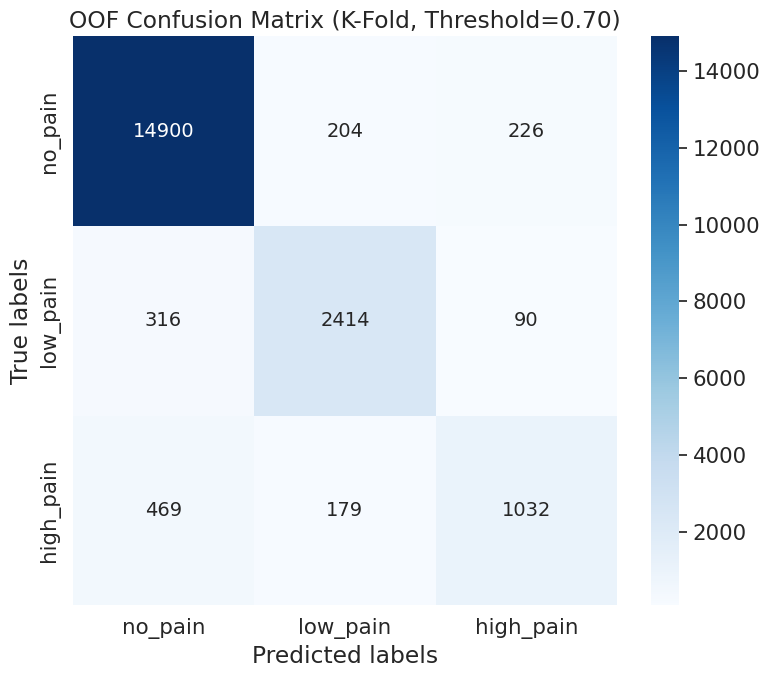

In [22]:
print("--- 📊 Finding Best Threshold on OOF Predictions ---")

best_f1 = 0
best_threshold = 1.0

# We test "penalizing" the no_pain probability. 
# A threshold < 1.0 makes it harder for 'no_pain' to win.
# A threshold > 1.0 makes it easier.
thresholds_to_test = [0.7, 0.8, 0.85, 0.9, 0.95, 1.0, 1.05, 1.1, 1.2, 1.3]

for threshold in thresholds_to_test:
    # Apply "Soft" Cascade Logic with the threshold
    # We multiply the 'no_pain' probability by the threshold
    final_prob_no_pain = all_oof_probs_m1[:, 0] * threshold
    final_prob_low_pain = all_oof_probs_m1[:, 1] * all_oof_probs_m2[:, 0]
    final_prob_high_pain = all_oof_probs_m1[:, 1] * all_oof_probs_m2[:, 1]
    
    # Combine and get argmax
    final_probs_combined = np.stack([final_prob_no_pain, final_prob_low_pain, final_prob_high_pain], axis=1)
    final_preds = np.argmax(final_probs_combined, axis=1)
    
    # Calculate F1
    f1 = f1_score(all_oof_targets_3class, final_preds, average='weighted', zero_division=0)
    print(f"Threshold: {threshold:.2f} -> Weighted F1: {f1:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"\n--- ✅ Best OOF F1: {best_f1:.4f} found at Threshold: {best_threshold:.2f} ---")

# --- Plot Final OOF Confusion Matrix with Best Threshold ---
print("Generating final OOF Confusion Matrix...")
final_prob_no_pain = all_oof_probs_m1[:, 0] * best_threshold
final_prob_low_pain = all_oof_probs_m1[:, 1] * all_oof_probs_m2[:, 0]
final_prob_high_pain = all_oof_probs_m1[:, 1] * all_oof_probs_m2[:, 1]
final_probs_combined = np.stack([final_prob_no_pain, final_prob_low_pain, final_prob_high_pain], axis=1)
final_preds = np.argmax(final_probs_combined, axis=1)

target_names = ['no_pain', 'low_pain', 'high_pain']
report = classification_report(all_oof_targets_3class, final_preds, target_names=target_names, zero_division=0)
print(report)

cm = confusion_matrix(all_oof_targets_3class, final_preds)
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title(f'OOF Confusion Matrix (K-Fold, Threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

## 🚀 Inference & Submission (Ensembled)

In [31]:
print("--- 🚀 Starting Prediction on Public Test Set (Ensembled) ---")

# --- 1. Prepare Test Data (same as before) ---
X_test_flat = df_public_test.copy()
BEST_WINDOW = best_params_m1['WINDOW']
BEST_STRIDE = best_params_m1['STRIDE']

# Corrected function call without the **
X_test_seq_cont, X_test_seq_cat, test_index_map = create_test_sliding_windows(
    X_test_flat, 
    continuous_cols=continuous_feature_cols, 
    categorical_cols=categorical_feature_cols, 
    window=BEST_WINDOW, # Corrected
    stride=BEST_STRIDE   # Corrected
)

test_ds = TensorDataset(torch.from_numpy(X_test_seq_cont), torch.from_numpy(X_test_seq_cat))
test_loader = make_loader(test_ds, batch_size=FINAL_BATCH_SIZE, shuffle=False, drop_last=False)
print(f"Test loader created with {len(test_ds)} windows.")

# --- 2. Generate Predictions from ALL K-Fold models ---
fold_logits_m1_list = []
fold_logits_m2_list = []

# Load models from each fold and predict
for fold in range(N_SPLITS):
    print(f"Loading and predicting with models from Fold {fold+1}...")
    
    # Load Model 1
    model_1 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=best_params_m1["time_embedding_dim"], cnn_out_channels=best_params_m1["cnn_out_channels"],
        hidden_size=best_params_m1["hidden_size"], num_layers=best_params_m1["num_layers"],
        num_classes=NUM_CLASSES_M1, dropout_rate=best_params_m1["dropout_rate"],
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)
    model_1.load_state_dict(torch.load(f"models/model_1_fold_{fold}_final_model.pt", map_location=device))
    model_1.eval()

    # Load Model 2
    model_2 = RecurrentAttentionClassifier(
        continuous_input_size=CONTINUOUS_FEATURE_SIZE, time_vocab_size=TIME_VOCAB_SIZE,
        time_embedding_dim=best_params_m1["time_embedding_dim"], cnn_out_channels=best_params_m1["cnn_out_channels"],
        hidden_size=best_params_m2["hidden_size"], num_layers=best_params_m2["num_layers"],
        num_classes=NUM_CLASSES_M2, dropout_rate=best_params_m2["dropout_rate"],
        bidirectional=True, rnn_type="GRU", use_layer_norm=True
    ).to(device)
    model_2.load_state_dict(torch.load(f"models/model_2_fold_{fold}_final_model.pt", map_location=device))
    model_2.eval()

    all_logits_m1, all_logits_m2 = [], []
    with torch.no_grad():
        for (inputs_cont, inputs_cat) in test_loader: 
            inputs_cont, inputs_cat = inputs_cont.to(device), inputs_cat.to(device)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits_m1 = model_1(inputs_cont, inputs_cat)
                logits_m2 = model_2(inputs_cont, inputs_cat)
            all_logits_m1.append(logits_m1.cpu().numpy())
            all_logits_m2.append(logits_m2.cpu().numpy())
    
    fold_logits_m1_list.append(np.concatenate(all_logits_m1))
    fold_logits_m2_list.append(np.concatenate(all_logits_m2))

# --- 3. Average Logits Across Folds ---
# Average the logits *before* softmax
avg_logits_m1 = np.mean(fold_logits_m1_list, axis=0)
avg_logits_m2 = np.mean(fold_logits_m2_list, axis=0)
print(f"Generated and averaged logits for {len(avg_logits_m1)} windows.")

# --- 4. Aggregate Logits by Sample Index (Averaging) ---
print("Aggregating window predictions...")
pred_df = pd.DataFrame({'sample_index': test_index_map})
pred_df['logit_m1_0'] = avg_logits_m1[:, 0]
pred_df['logit_m1_1'] = avg_logits_m1[:, 1]
pred_df['logit_m2_0'] = avg_logits_m2[:, 0]
pred_df['logit_m2_1'] = avg_logits_m2[:, 1]

submission_logits_m1 = pred_df.groupby('sample_index')[['logit_m1_0', 'logit_m1_1']].mean()
submission_logits_m2 = pred_df.groupby('sample_index')[['logit_m2_0', 'logit_m2_1']].mean()

# --- 5. Apply \"Soft\" Cascade Logic with BEST Threshold ---
print(f"Applying 'soft' cascade logic with best_threshold={best_threshold:.2f}...")

def softmax(x):
    e_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e_x / e_x.sum(axis=1, keepdims=True)

# Convert averaged logits to probabilities
probs_m1_df = pd.DataFrame(
    softmax(submission_logits_m1.values), 
    index=submission_logits_m1.index, 
    columns=['prob_m1_0', 'prob_m1_1']
)
probs_m2_df = pd.DataFrame(
    softmax(submission_logits_m2.values), 
    index=submission_logits_m2.index, 
    columns=['prob_m2_0', 'prob_m2_1']
)

# Apply the cascade logic WITH the tuned threshold:
final_prob_no_pain = probs_m1_df['prob_m1_0'] * best_threshold # Apply best threshold
final_prob_low_pain = probs_m1_df['prob_m1_1'] * probs_m2_df['prob_m2_0']
final_prob_high_pain = probs_m1_df['prob_m1_1'] * probs_m2_df['prob_m2_1']

# Combine into a single DataFrame
final_probs_combined_df = pd.concat(
    [final_prob_no_pain, final_prob_low_pain, final_prob_high_pain], 
    axis=1
)
final_probs_combined_df.columns = ['prob_0', 'prob_1', 'prob_2']

# Get the argmax (the class with the highest probability)
final_numeric_predictions = final_probs_combined_df.idxmax(axis=1).str.replace('prob_', '').astype(int)
final_numeric_predictions.name = 'prediction'

# --- 6. Create Submission File ---
inverse_label_map = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
final_labels = final_numeric_predictions.map(inverse_label_map)

# Convert the integer index (e.g., 1) to a formatted string (e.g., "001")
formatted_index = final_numeric_predictions.index.astype(str).str.zfill(3)

# Create the submission DataFrame with the formatted index
submission_df = pd.DataFrame({'sample_index': formatted_index, 'label': final_labels})
submission_df.to_csv('submission.csv', index=False)

print(f"\nSuccessfully saved 'submission.csv' with {len(submission_df)} rows.")
print(submission_df.head())

--- 🚀 Starting Prediction on Public Test Set (Ensembled) ---
Test loader created with 39720 windows.
Loading and predicting with models from Fold 1...
Loading and predicting with models from Fold 2...
Loading and predicting with models from Fold 3...
Loading and predicting with models from Fold 4...
Loading and predicting with models from Fold 5...
Generated and averaged logits for 39720 windows.
Aggregating window predictions...
Applying 'soft' cascade logic with best_threshold=0.70...

Successfully saved 'submission.csv' with 1324 rows.
             sample_index    label
sample_index                      
0                     000  no_pain
1                     001  no_pain
2                     002  no_pain
3                     003  no_pain
4                     004  no_pain


In [32]:
submission_df.describe()

,sample_index,label
count,1324,1324
unique,1324,3
top,1323,no_pain
freq,1,1054
